In [2]:
# !pip install kaggle
# !pip install kagglehub

In [2]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense , Conv2D , MaxPool2D , Flatten , BatchNormalization , Dropout

In [4]:
# Load the training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory='./Data/dogs-vs-cats',
    labels='inferred',
    validation_split=0.2,
    subset="training",  # specifying training subset
    seed=123,
    image_size=(256, 256),
    batch_size=32,
    label_mode="int"
)

# Load the validation dataset
validation_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory='./Data/dogs-vs-cats',
    labels='inferred',
    validation_split=0.2,
    subset="validation",  # specifying validation subset
    seed=123,
    image_size=(256, 256),
    batch_size=32,
    label_mode="int"
)

Found 10000 files belonging to 2 classes.
Using 8000 files for training.
Found 10000 files belonging to 2 classes.
Using 2000 files for validation.


In [11]:
import os
print(os.getcwd())

/content


In [ ]:
class_names = train_ds.class_names
print(class_names)

['cat', 'dog']


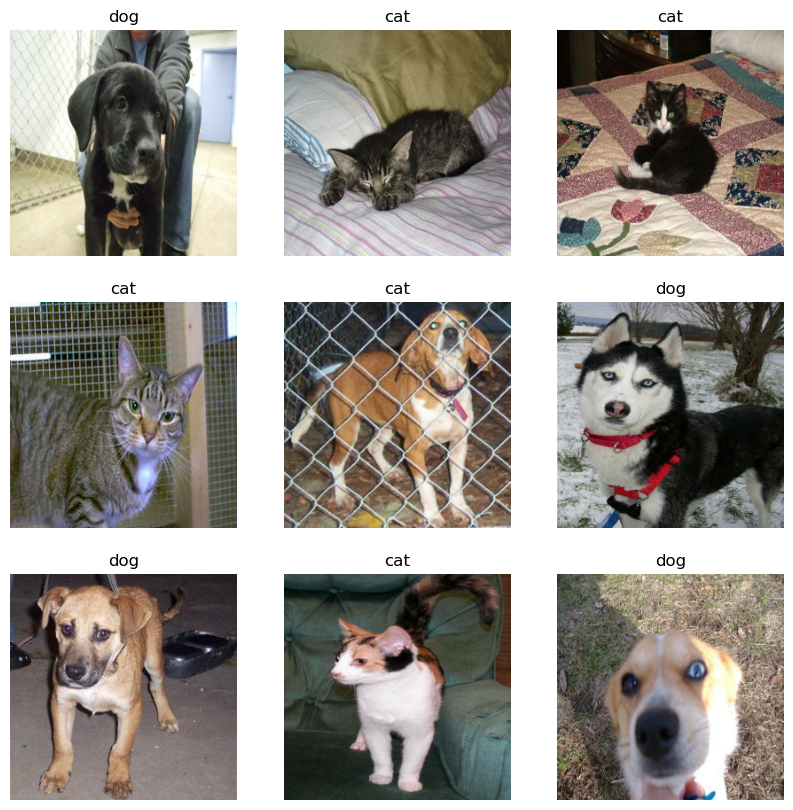

In [ ]:
# Visualize a batch of images
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
# Normalize the images
def normalize_images(image, label):
    image = image / 255.0  # Normalize to [0, 1]
    return image, label

train_ds = train_ds.map(normalize_images)
validation_ds = validation_ds.map(normalize_images)

In [ ]:
model = Sequential()

# Convolution and MaxPooling layers
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2), padding='valid', strides=2))

model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2), padding='valid', strides=2))

# Flatten layer
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid')) 

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 638s 3s/step - accuracy: 0.5076 - loss: 0.7265 - val_accuracy: 0.5445 - val_loss: 0.6891
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 636s 2s/step - accuracy: 0.5718 - loss: 0.6759 - val_accuracy: 0.6705 - val_loss: 0.6222
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 544s 2s/step - accuracy: 0.6956 - loss: 0.5888 - val_accuracy: 0.6990 - val_loss: 0.6082
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 620s 2s/step - accuracy: 0.7710 - loss: 0.4660 - val_accuracy: 0.7015 - val_loss: 0.6989
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 630s 3s/step - accuracy: 0.8864 - loss: 0.2632 - val_accuracy: 0.6920 - val_loss: 1.0643
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 597s 2s/step - accuracy: 0.9548 - loss: 0.1172 - val_accuracy: 0.6670 - val_loss: 1.4356
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - accuracy: 0.9666 - loss: 0.1005 - val_accuracy: 0.6855 - val_loss: 1.5202
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 521s 2s/step - accuracy: 0.9765 - loss: 0.0717 - val_accu

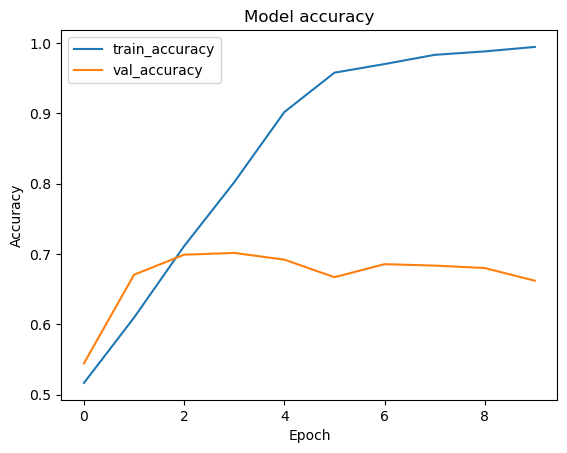

In [ ]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history.get('val_accuracy', []), label='val_accuracy')
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()